In [1]:
import pandas 
import numpy as np
import moments 
import dpluspy 
import scipy
import demes
import demesdraw
import matplotlib
import matplotlib.pylab as plt


In [2]:
matplotlib.rc("font", size=8)
matplotlib.rc("xtick", labelsize=8)
matplotlib.rc("ytick", labelsize=8)
matplotlib.rc("axes", labelsize=8)
matplotlib.rc("axes", titlesize=8)
matplotlib.rc("legend", fontsize=8)


In [3]:
rs = np.logspace(-6, -2, 48)
u = 1e-8

# admixture model
b = demes.Builder()
b.add_deme("A", epochs=[{"start_size": 1e4, "end_time": 2e4}])
b.add_deme("X", ancestors=["A"], epochs=[{"start_size": 1e4, "end_time": 0}])
b.add_deme("Y", ancestors=["A"], epochs=[{"start_size": 1e4, "end_time": 0}])
b.add_pulse(sources=["Y"], dest="X", proportions=[0.10], time=5000)
g = b.resolve()

y0 = moments.Demes.LD(g, sampled_demes=["X", "Y"], r=rs, u=u, sample_times=[5001, 5001])
y1 = moments.Demes.LD(g, sampled_demes=["X", "Y"], r=rs, u=u, sample_times=[4999, 4999])
y2 = moments.Demes.LD(g, sampled_demes=["X", "Y"], r=rs, u=u, sample_times=[0, 0])


_rs = [1e-6, 2e-5, 1e-3]
ts = np.linspace(0, 6000, 101)
time_course = []
for t in ts: 
    y = moments.Demes.LD(g, sampled_demes=["X", "Y"], r=_rs, u=u, sample_times=[t, t])  
    time_course.append(y.H2(0, 1))
time_course = np.array(time_course)

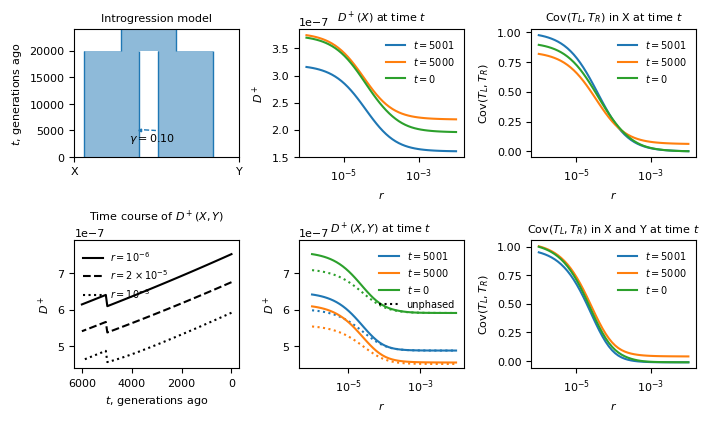

In [ ]:
mosaic = """
ABC
DEF
"""
fig, axs = plt.subplot_mosaic(
    mosaic, figsize=(7, 4.1), layout="constrained")

demesdraw.tubes(
    g, 
    ax=axs["A"],
    colours="tab:blue",
    max_time=2.4e4,
    positions={"A": 15000, "X": 0, "Y": 30000},
    labels=None
)
axs["A"].spines["top"].set_visible(True)
axs["A"].spines["right"].set_visible(True)
axs["A"].spines["bottom"].set_visible(True)
axs["A"].set_title("Introgression model")
axs["A"].annotate(r"$\gamma=0.10$", (10000, 3e3))
axs["A"].tick_params(axis="x", reset=True, bottom=True, top=False)
axs["A"].set_xticks([0, 30000], ["X", "Y"])
axs["A"].set_ylabel("$t$, generations ago")

theta0 = y0.H()[0]
cv0 = (y0.H2(0) - theta0 ** 2) / (theta0 ** 2)
theta1 = y1.H()[0]
cv1 = (y1.H2(0) - theta1 ** 2) / (theta1 ** 2)
theta2 = y2.H()[0]
cv2 = (y2.H2(0) - theta2 ** 2) / (theta2 ** 2)

axs["B"].set_title("$D^+(X)$ at time $t$")
axs["B"].set_xscale("log")
axs["B"].plot(rs, y0.H2(0), label="$t=5001$")
axs["B"].plot(rs, y1.H2(0), label="$t=5000$")
axs["B"].plot(rs, y2.H2(0), label="$t=0$")
axs["B"].legend(framealpha=0, fontsize=7)
axs["B"].set_ylabel("$D^+$")
axs["B"].set_xlabel("$r$")

axs["C"].set_title(r"$\operatorname{Cov}(T_L, T_R)$ in X at time $t$")
axs["C"].set_xscale("log")
axs["C"].plot(rs, cv0, label="$t=5001$")
axs["C"].plot(rs, cv1, label="$t=5000$")
axs["C"].plot(rs, cv2, label="$t=0$")
axs["C"].legend(framealpha=0, fontsize=7)
axs["C"].set_ylabel(r"$\operatorname{Cov}(T_L, T_R)$")
axs["C"].set_xlabel("$r$")


axs["D"].set_title("Time course of $D^+(X, Y)$")
axs["D"].plot(ts, time_course[:, 0], label="$r=10^{-6}$", color="black")
axs["D"].plot(ts, time_course[:, 1], label=r"$r=2\times 10^{-5}$", color="black", linestyle="dashed")
axs["D"].plot(ts, time_course[:, 2], label="$r=10^{-3}$", color="black", linestyle="dotted")
axs["D"].legend(framealpha=0, fontsize=7)
axs["D"].invert_xaxis()
axs["D"].set_xlabel("$t$, generations ago")
axs["D"].set_ylabel("$D^+$")


axs["E"].set_title("$D^+(X, Y)$ at time $t$")
axs["E"].set_xscale("log")
axs["E"].plot(rs, y0.H2(0, 1), label="$t=5001$", color="tab:blue")
axs["E"].plot(rs, y0.H2(0, 1, phased=False), color="tab:blue", linestyle="dotted")

axs["E"].plot(rs, y1.H2(0, 1), label="$t=5000$", color="tab:orange")
axs["E"].plot(rs, y1.H2(0, 1, phased=False), color="tab:orange", linestyle="dotted")

axs["E"].plot(rs, y2.H2(0, 1), label="$t=0$", color="tab:green")
axs["E"].plot(rs, y2.H2(0, 1, phased=False),  color="tab:green", linestyle="dotted")

axs["E"].plot([7e-7], [7e-7], color="black", linestyle="dotted", label="unphased")
axs["E"].legend(framealpha=0, fontsize=7)
axs["E"].set_ylabel("$D^+$")
axs["E"].set_xlabel("$r$")


ET0 = y0.H()[1] / (2 * u)
ET1 = y1.H()[1] / (2 * u)
ET2 = y2.H()[1] / (2 * u)
cvXY0 = (y0.H2(0, 1) / (4 * u ** 2) - ET0 ** 2) / (20000) ** 2
cvXY1 = (y1.H2(0, 1) / (4 * u ** 2) - ET1 ** 2) / (20000) ** 2
cvXY2 = (y2.H2(0, 1) / (4 * u ** 2) - ET2 ** 2) / (20000) ** 2

axs["F"].set_title(r"$\operatorname{Cov}(T_L, T_R)$ in X and Y at time $t$")
axs["F"].set_xscale("log")
axs["F"].plot(rs, cvXY0, label="$t=5001$", color="tab:blue")
axs["F"].plot(rs, cvXY1, label="$t=5000$", color="tab:orange")
axs["F"].plot(rs, cvXY2, label="$t=0$", color="tab:green")
axs["F"].legend(framealpha=0, fontsize=7)
axs["F"].set_ylabel(r"$\operatorname{Cov}(T_L, T_R)$")
axs["F"].set_xlabel("$r$")

axs["D"].sharey(axs["E"])
axs["D"].set_ylim(4.4e-7, 7.9e-7)

plt.savefig("theory_figure.svg", transparent=True)

In [5]:
ET1 = y1.H()[1] / (2 * u)
print(ET0)
print((y1.H2(0, 1) / (4 * u ** 2) - ET1 ** 2) / (20000) ** 2)

34999.00000000003
[1.00228376 0.99429494 0.984708   0.97323603 0.95955545 0.94330809
 0.92410713 0.90154842 0.87522878 0.84477294 0.8098703  0.77032128
 0.72609143 0.67736847 0.62461408 0.56859912 0.51040943 0.45141012
 0.39316177 0.33729074 0.28532794 0.2385413  0.19779445 0.16346335
 0.13543239 0.11317252 0.09588126 0.0826459  0.07258664 0.06494872
 0.05913647 0.05470309 0.05131911 0.04873894 0.04677519 0.04528254
 0.0441478  0.04328329 0.0426216  0.04211126 0.04171317 0.04139765
 0.04114211 0.04092923 0.04074547 0.04058001 0.04042387 0.04026925]


In [6]:
y0.H2(0, 0) / (4 * u ** 2)

array([7.89599171e+08, 7.87415467e+08, 7.84790430e+08, 7.81642684e+08,
       7.77879355e+08, 7.73396032e+08, 7.68077551e+08, 7.61799973e+08,
       7.54434185e+08, 7.45851536e+08, 7.35931858e+08, 7.24574001e+08,
       7.11708616e+08, 6.97312325e+08, 6.81421749e+08, 6.64145138e+08,
       6.45668976e+08, 6.26257046e+08, 6.06240339e+08, 5.85997805e+08,
       5.65929877e+08, 5.46428477e+08, 5.27848074e+08, 5.10482099e+08,
       4.94547693e+08, 4.80179869e+08, 4.67434339e+08, 4.56297029e+08,
       4.46697702e+08, 4.38525255e+08, 4.31642672e+08, 4.25900291e+08,
       4.21146581e+08, 4.17236167e+08, 4.14035182e+08, 4.11424282e+08,
       4.09299796e+08, 4.07573520e+08, 4.06171637e+08, 4.05033141e+08,
       4.04108092e+08, 4.03355876e+08, 4.02743612e+08, 4.02244739e+08,
       4.01837830e+08, 4.01505597e+08, 4.01234081e+08, 4.01011996e+08])

In [7]:
(2 * 10000) ** 2

400000000